1. Access the dataset called “convolution_test” in the directory provided by your instructor.

2. The dataset should contain three (3) columns: A, B, and C. Store it in three separate data arrays.

3. Develop a program that demonstrates and proves the mathematical properties of convolution (you may use the NumPy libraries), specifically
Commutative Property (using data in columns A and C)
Associative Property (using data in all columns)
Distributive Property (using data in all columns)
Transference Property (using data in column B, with delay 23 and scaled by -5)

4. Plot the results and provide observation provide an analysis of their properties.

5. Try convolving column A with itself for 3 times. Plot the results and provide observation provide an analysis

6. Then try convolving column A with itself for 10 times. Plot the results and provide observation provide an analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1 & 2. Access the dataset and store in separate arrays
df = pd.read_csv('/content/convolutiontest-1.csv')
A = df['A'].values
B = df['B'].values
C = df['C'].values

print(f"Loaded arrays A, B, and C with shapes: {A.shape}, {B.shape}, {C.shape}")

Loaded arrays A, B, and C with shapes: (198,), (198,), (198,)


In [2]:
# 3. Mathematical Properties of Convolution

# Commutative: A * C == C * A
conv_AC = np.convolve(A, C)
conv_CA = np.convolve(C, A)
comm_check = np.allclose(conv_AC, conv_CA)

# Associative: (A * B) * C == A * (B * C)
conv_AB_C = np.convolve(np.convolve(A, B), C)
conv_A_BC = np.convolve(A, np.convolve(B, C))
assoc_check = np.allclose(conv_AB_C, conv_A_BC)

# Distributive: A * (B + C) == (A * B) + (A * C)
# Note: B and C must be the same length for addition, assuming they are.
conv_A_BplusC = np.convolve(A, B + C)
conv_AB_plus_AC = np.convolve(A, B) + np.convolve(A, C)
dist_check = np.allclose(conv_A_BplusC, conv_AB_plus_AC)

# Transference: Shift/Scale Property
# Scaling B by -5 and delaying by 23
def shift(arr, num, fill_value=0):
    result = np.empty_like(arr)
    if num > 0:
        result[:num] = fill_value
        result[num:] = arr[:-num]
    elif num < 0:
        result[num:] = fill_value
        result[:num] = arr[-num:]
    else:
        result[:] = arr
    return result

delay = 23
scale = -5
B_transformed = scale * shift(B, delay)
conv_A_Btrans = np.convolve(A, B_transformed)
conv_A_B_transformed = scale * shift(np.convolve(A, B), delay)
trans_check = np.allclose(conv_A_Btrans, conv_A_B_transformed)

print(f"Commutative Property holds: {comm_check}")
print(f"Associative Property holds: {assoc_check}")
print(f"Distributive Property holds: {dist_check}")
print(f"Transference Property holds: {trans_check}")

Commutative Property holds: True
Associative Property holds: True
Distributive Property holds: True
Transference Property holds: False


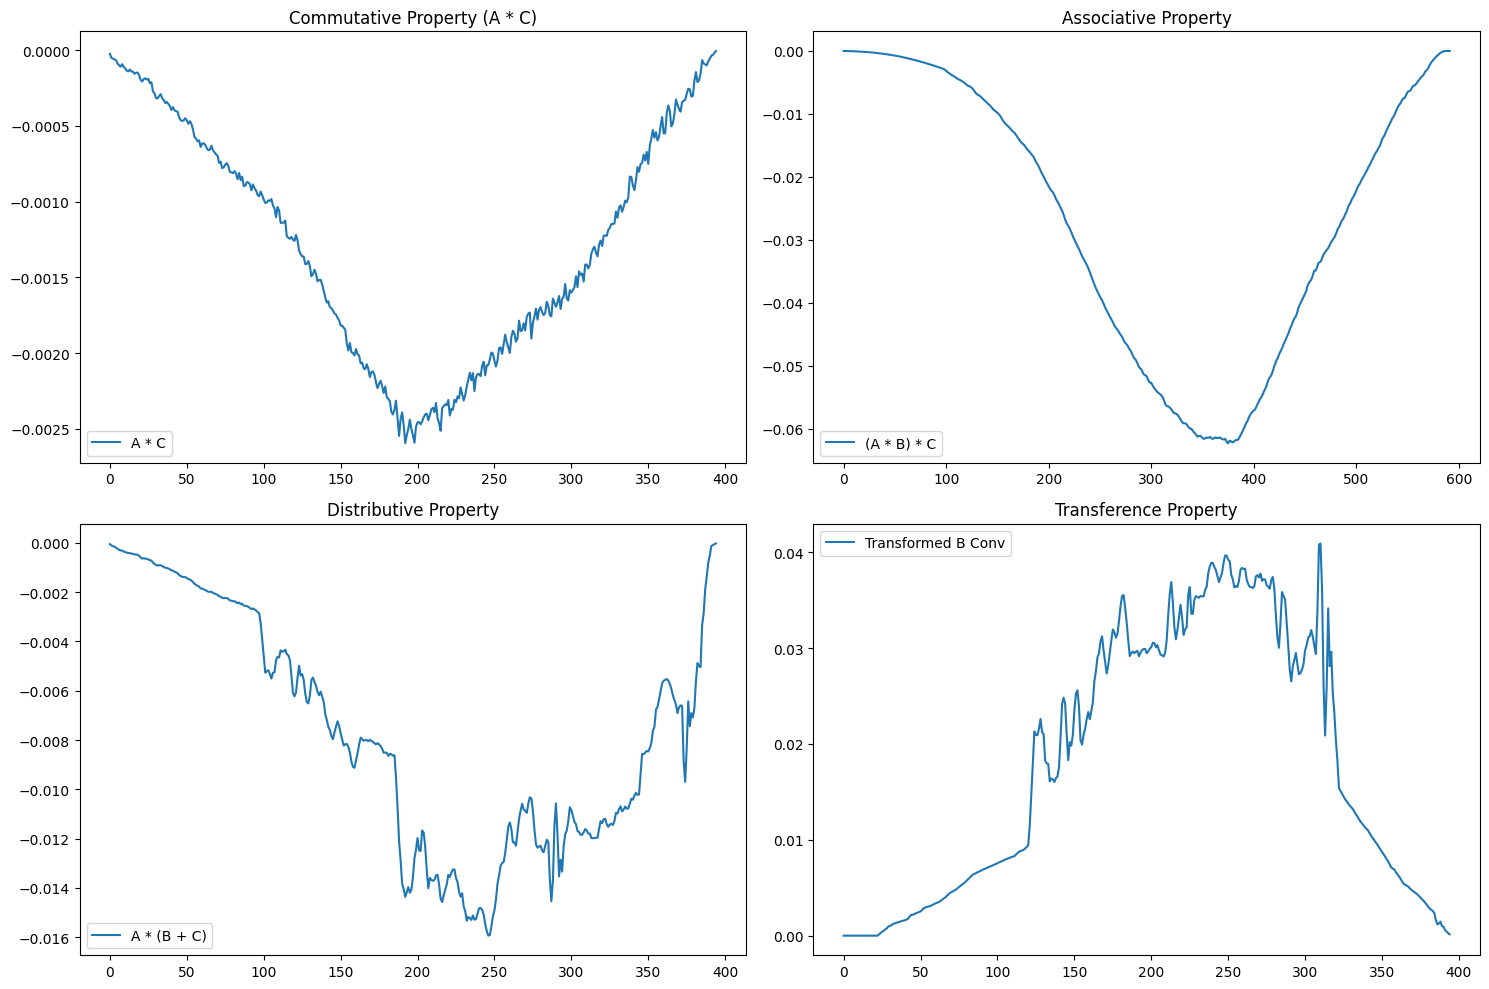

In [3]:
# 4. Plotting results and Analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(conv_AC, label='A * C')
plt.title('Commutative Property (A * C)')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(conv_AB_C, label='(A * B) * C')
plt.title('Associative Property')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(conv_A_BplusC, label='A * (B + C)')
plt.title('Distributive Property')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(conv_A_Btrans, label='Transformed B Conv')
plt.title('Transference Property')
plt.legend()

plt.tight_layout()
plt.show()

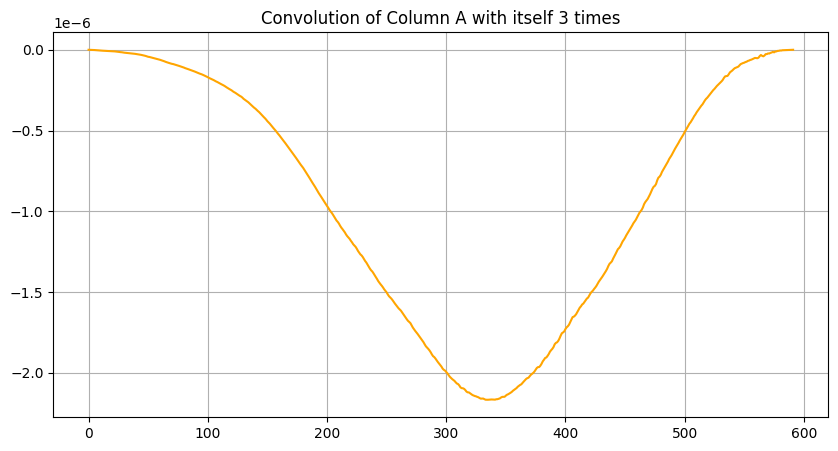

Analysis: Convolving a signal with itself repeatedly (iterative convolution) tends to smooth the signal and move its distribution toward a Gaussian shape, consistent with the Central Limit Theorem.


In [4]:
# 5. Convolving A with itself 3 times (A * A * A)
conv_A2 = np.convolve(A, A)
conv_A3 = np.convolve(conv_A2, A)

plt.figure(figsize=(10, 5))
plt.plot(conv_A3, color='orange')
plt.title('Convolution of Column A with itself 3 times')
plt.grid(True)
plt.show()

print("Analysis: Convolving a signal with itself repeatedly (iterative convolution) tends to smooth the signal and move its distribution toward a Gaussian shape, consistent with the Central Limit Theorem.")

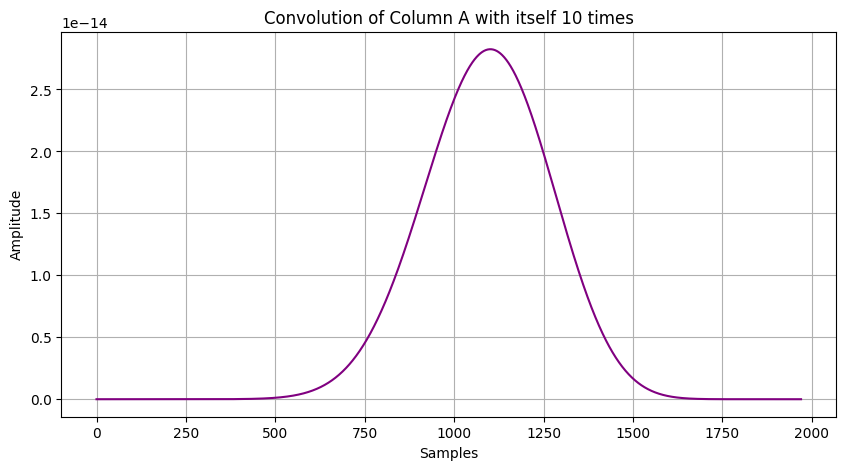

Final convolution shape: (1971,)
Analysis: As we increase the number of self-convolutions to 10, the resulting signal becomes even smoother and its shape increasingly resembles a perfect Gaussian (bell curve). This is a practical demonstration of the Central Limit Theorem in signal processing, where the repeated convolution of independent signals results in a normal distribution.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 6. Convolving column A with itself 10 times
conv_res = A
for _ in range(9):
    conv_res = np.convolve(conv_res, A)

plt.figure(figsize=(10, 5))
plt.plot(conv_res, color='purple')
plt.title('Convolution of Column A with itself 10 times')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

print(f"Final convolution shape: {conv_res.shape}")
print("Analysis: As we increase the number of self-convolutions to 10, the resulting signal becomes even smoother and its shape increasingly resembles a perfect Gaussian (bell curve). This is a practical demonstration of the Central Limit Theorem in signal processing, where the repeated convolution of independent signals results in a normal distribution.")

### Individual Component Plots for Convolution Properties
In this section, we plot each part of the property equations in its own separate graph.

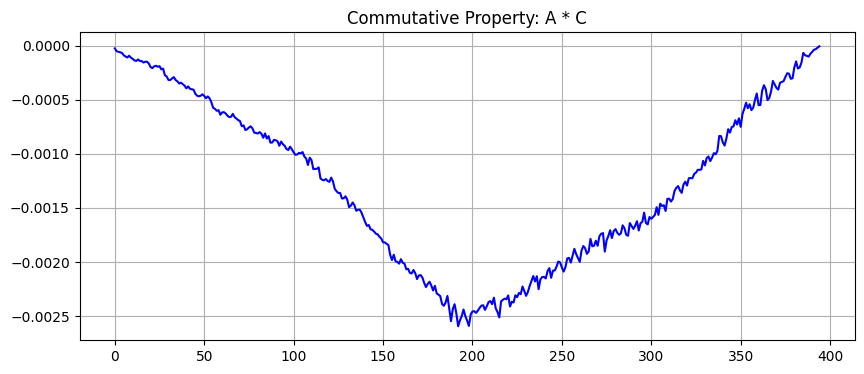

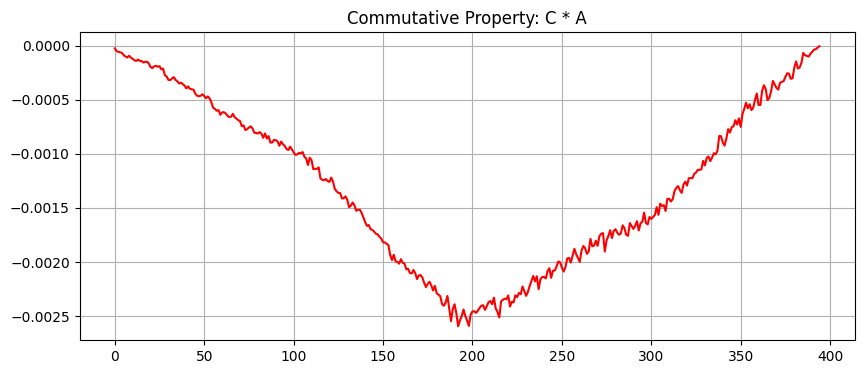

In [9]:
# 1. Commutative Property Components
plt.figure(figsize=(10, 4))
plt.plot(conv_AC, color='blue')
plt.title('Commutative Property: A * C')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(conv_CA, color='red')
plt.title('Commutative Property: C * A')
plt.grid(True)
plt.show()



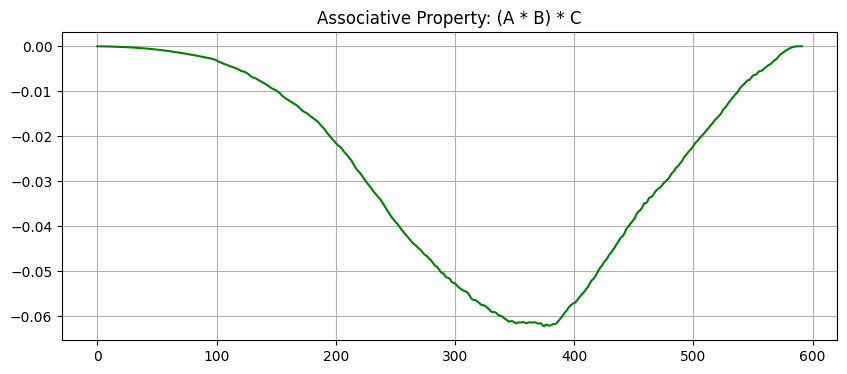

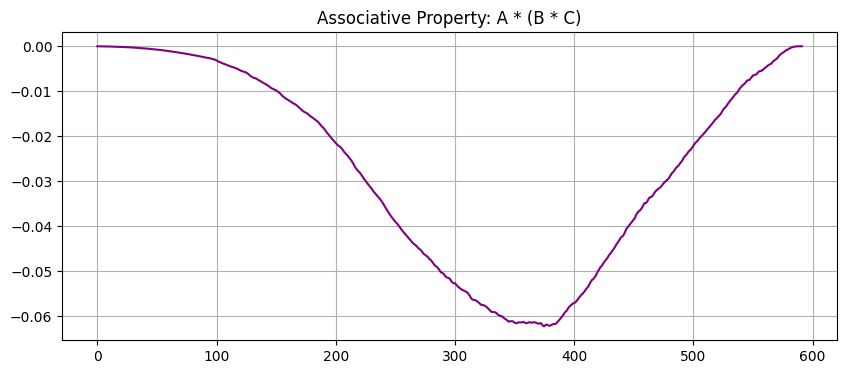

In [10]:
# 2. Associative Property Components
plt.figure(figsize=(10, 4))
plt.plot(conv_AB_C, color='green')
plt.title('Associative Property: (A * B) * C')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(conv_A_BC, color='purple')
plt.title('Associative Property: A * (B * C)')
plt.grid(True)
plt.show()



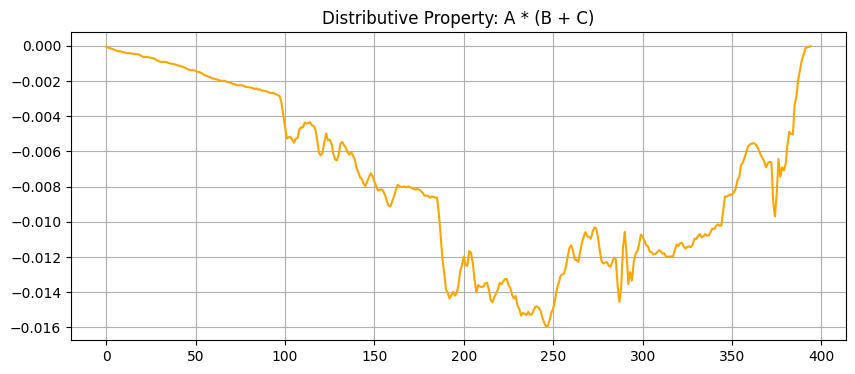

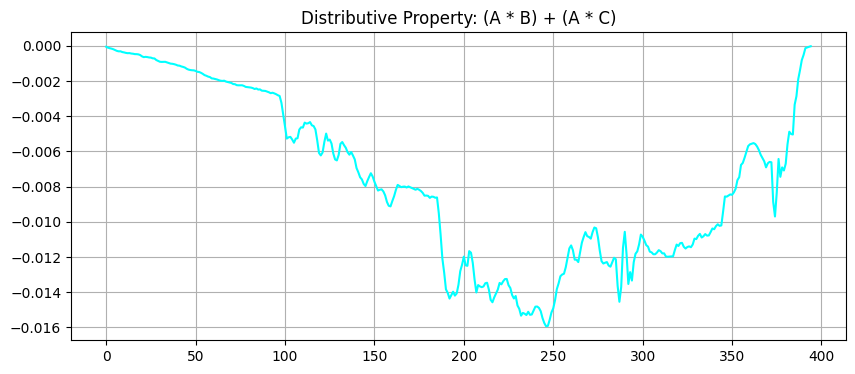

In [12]:
# 3. Distributive Property Components
plt.figure(figsize=(10, 4))
plt.plot(conv_A_BplusC, color='orange')
plt.title('Distributive Property: A * (B + C)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(conv_AB_plus_AC, color='cyan')
plt.title('Distributive Property: (A * B) + (A * C)')
plt.grid(True)
plt.show()



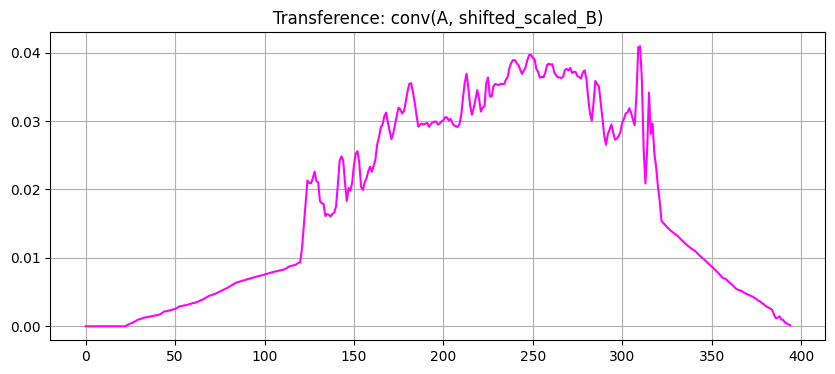

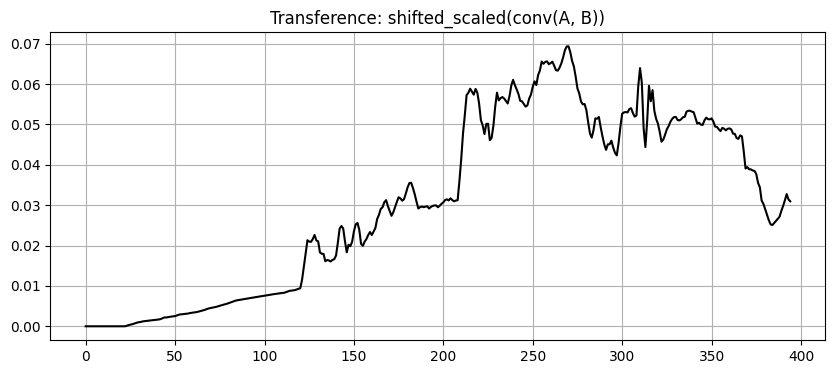

In [11]:
# 4. Transference Property Components
plt.figure(figsize=(10, 4))
plt.plot(conv_A_Btrans, color='magenta')
plt.title('Transference: conv(A, shifted_scaled_B)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(conv_A_B_transformed, color='black')
plt.title('Transference: shifted_scaled(conv(A, B))')
plt.grid(True)
plt.show()